# Aromas piloto 2026 — producción calibrada sólo con vino

## tl;dr

Los parámetros biológicos se estiman exclusivamente desde la química líquida. El condensado no participa en el objetivo y se utiliza como prueba independiente del contrato `eta_AB=1` más partición de Morakul/Mouret.

## Contexto y métodos

### Supuestos clave

- Captura conjunta A+B fijada a 1 por diseño, no estimada.
- Producción calibrada únicamente contra vino.
- Condensado completamente excluido del optimizador.
- Transferencia fijada como `K(E,T)·QCO2`.
- Validación leave-one-reactor-run-out en los seis procesos.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'fermentation_model').exists():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'fermentation_model'))
from pilot_2026 import run_aroma_wine_calibrated_complete_capture_2026 as analysis

result = analysis.load_results()
print('Veredicto:', result['gate']['verdict'])
print('Modelo diagnóstico:', result['gate']['diagnostic_best_model'])

Veredicto: NO_VALID_MODEL
Modelo diagnóstico: assumed_complete_capture_equilibrium


## Resultados

,analysis_policy,model_variant,species,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias
4,primary,assumed_complete_capture_delayed_response,ethyl_octanoate,wine,33,75.0941,31.9017,0.4248,19.6471,-4.3931
5,primary,assumed_complete_capture_delayed_response,isoamyl_acetate,wine,33,1026.5980,491.5406,0.4788,385.4143,-74.9051
6,primary,assumed_complete_capture_equilibrium,ethyl_octanoate,wine,33,75.0941,31.4896,0.4193,18.8086,-5.1671
7,primary,assumed_complete_capture_equilibrium,isoamyl_acetate,wine,33,1026.5980,487.7461,0.4751,380.9020,-79.8792
12,primary,assumed_complete_capture_delayed_response,ethyl_octanoate,condensate,19,395.7461,1865.7253,4.7145,1370.1130,1323.9177
13,primary,assumed_complete_capture_delayed_response,isoamyl_acetate,condensate,13,1697.7617,11726.7068,6.9072,9598.0955,9598.0955
14,primary,assumed_complete_capture_equilibrium,ethyl_octanoate,condensate,19,395.7461,1877.7573,4.7449,1359.0985,1301.2632
15,primary,assumed_complete_capture_equilibrium,isoamyl_acetate,condensate,13,1697.7617,11583.3241,6.8227,9456.6220,9456.6220


,model_variant,species,wine_nrmse,wine_threshold,wine_pass,independent_condensate_nrmse,condensate_threshold,condensate_closure_pass,wine_nrmse_reduction_vs_baseline,delayed_support_pass
0,assumed_complete_capture_equilibrium,ethyl_octanoate,0.4193,0.6,True,4.7449,1.0551,False,0.0000,True
1,assumed_complete_capture_equilibrium,isoamyl_acetate,0.4751,0.6,True,6.8227,0.9693,False,0.0000,True
2,assumed_complete_capture_delayed_response,ethyl_octanoate,0.4248,0.6,True,4.7145,1.0551,False,-0.0131,False
3,assumed_complete_capture_delayed_response,isoamyl_acetate,0.4788,0.6,True,6.9072,0.9693,False,-0.0078,False


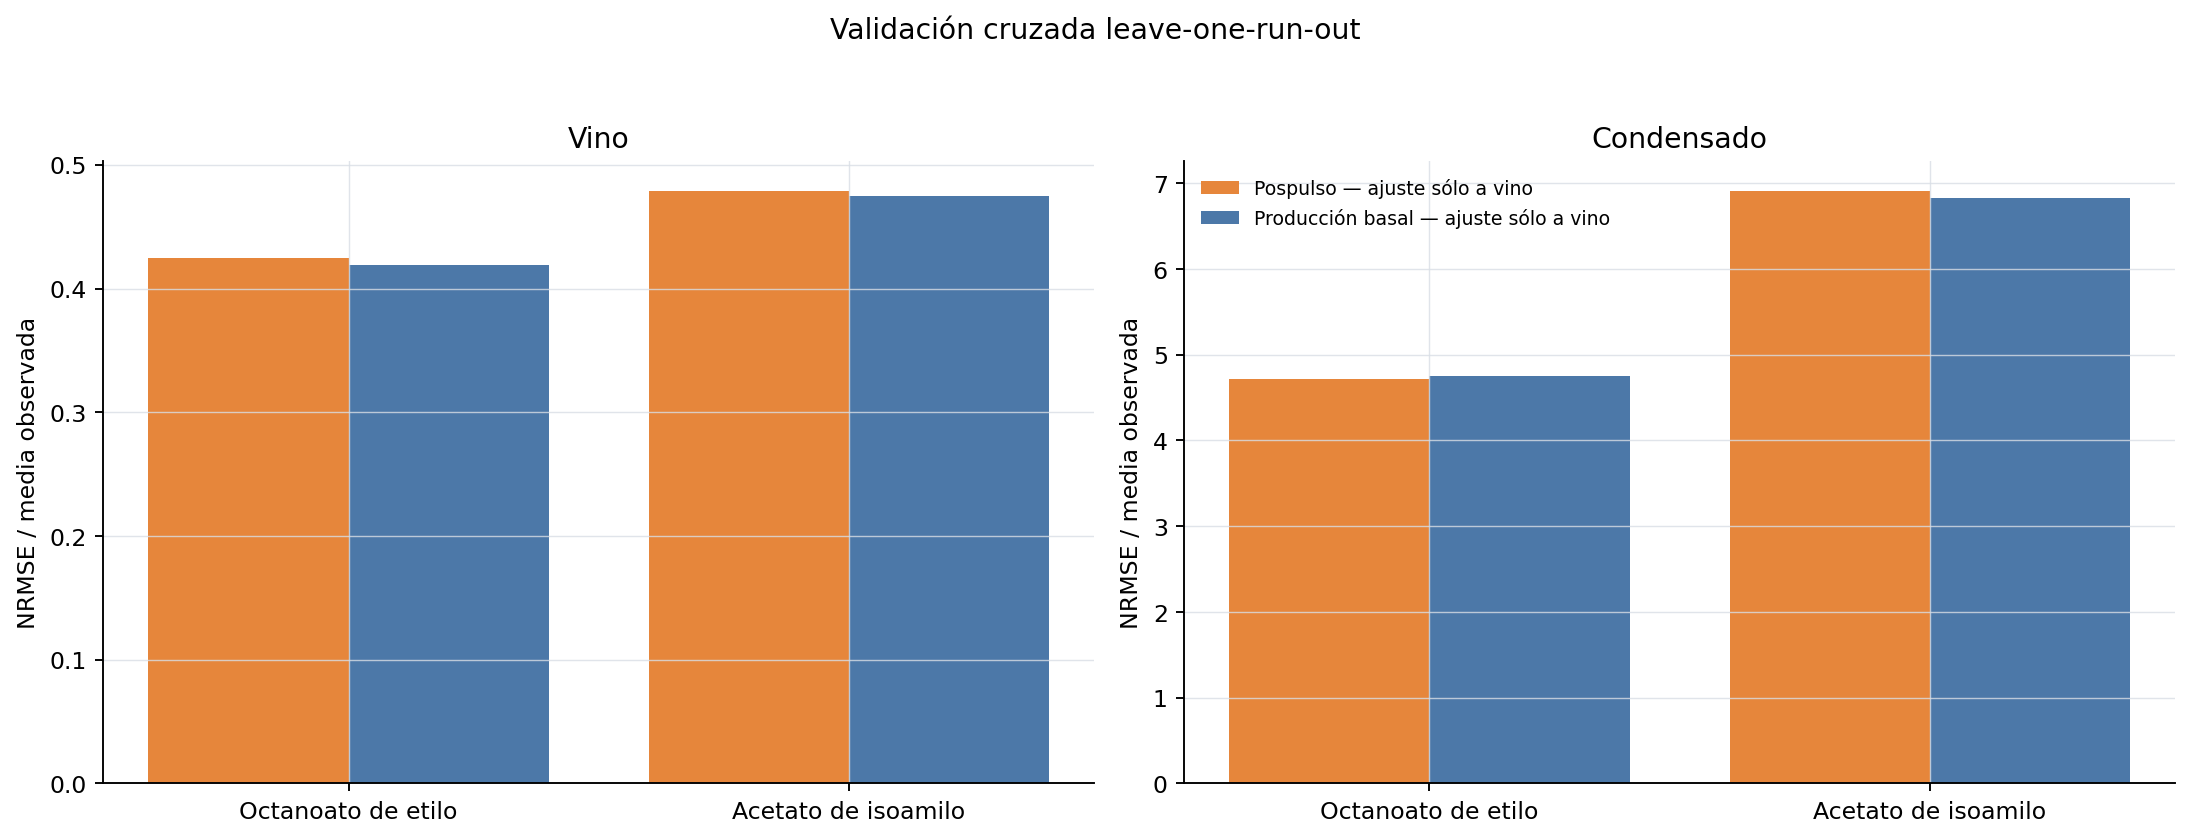

In [2]:
primary = result['metrics'].query("analysis_policy == 'primary'")
display(primary.round(4))
display(result['comparison'].round(4))
display(Image(filename=analysis.FIGURE_DIR / '02_loro_nrmse_comparison.png'))

In [3]:
display(result['closure'].round(4))
display(result['capture_audit'])
display(result['parameters'].round(5))

,model_variant,species,n_intervals,observed_total_ug,predicted_total_ug,predicted_to_observed_ratio,closure_difference_ug,intervals_overpredicted_fraction
0,assumed_complete_capture_delayed_response,ethyl_octanoate,19,7519.1755,32673.6113,4.3454,25154.4358,0.9474
1,assumed_complete_capture_delayed_response,isoamyl_acetate,13,22070.9026,146846.1436,6.6534,124775.2410,1.0000
2,assumed_complete_capture_equilibrium,ethyl_octanoate,19,7519.1755,32243.1769,4.2881,24724.0013,0.9474
3,assumed_complete_capture_equilibrium,isoamyl_acetate,13,22070.9026,145006.9889,6.5701,122936.0863,1.0000


,contract,fixed_total_capture_fraction,minimum_simulated_capture_fraction,maximum_simulated_capture_fraction,maximum_absolute_unrecovered_ug,maximum_absolute_mass_closure_error_ug,physical_efficiency_identified,interpretation
0,combined_A_plus_B_complete_capture,1.0,1.0,1.0,0.0,3.565219e-10,False,eta_AB=1 is imposed by design assumption; it i...


,fit_scope,species,model_variant,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
0,all_data,ethyl_octanoate,assumed_complete_capture_equilibrium,formation_growth_ug_per_g_sugar,1.09527,0.0001,10000.0,False,1.40330
1,all_data,ethyl_octanoate,assumed_complete_capture_equilibrium,formation_stationary_ug_per_g_sugar,0.74149,0.0001,10000.0,False,0.29711
2,all_data,isoamyl_acetate,assumed_complete_capture_equilibrium,formation_growth_ug_per_g_sugar,8.05407,0.0001,10000.0,False,2.48692
3,all_data,isoamyl_acetate,assumed_complete_capture_equilibrium,formation_stationary_ug_per_g_sugar,9.67236,0.0001,10000.0,False,0.36984
4,all_data,ethyl_octanoate,assumed_complete_capture_delayed_response,formation_growth_ug_per_g_sugar,1.22466,0.0001,10000.0,False,1.61315
5,all_data,ethyl_octanoate,assumed_complete_capture_delayed_response,formation_stationary_ug_per_g_sugar,0.53762,0.0001,10000.0,False,0.99914
6,all_data,ethyl_octanoate,assumed_complete_capture_delayed_response,pulse_formation_ug_per_g_sugar,0.66189,0.0001,10000.0,False,2.14615
7,all_data,ethyl_octanoate,assumed_complete_capture_delayed_response,activation_peak_h,8.70016,1.0000,120.0,False,3.00309
8,all_data,isoamyl_acetate,assumed_complete_capture_delayed_response,formation_growth_ug_per_g_sugar,7.74687,0.0001,10000.0,False,2.56216
9,all_data,isoamyl_acetate,assumed_complete_capture_delayed_response,formation_stationary_ug_per_g_sugar,9.15763,0.0001,10000.0,False,0.50060


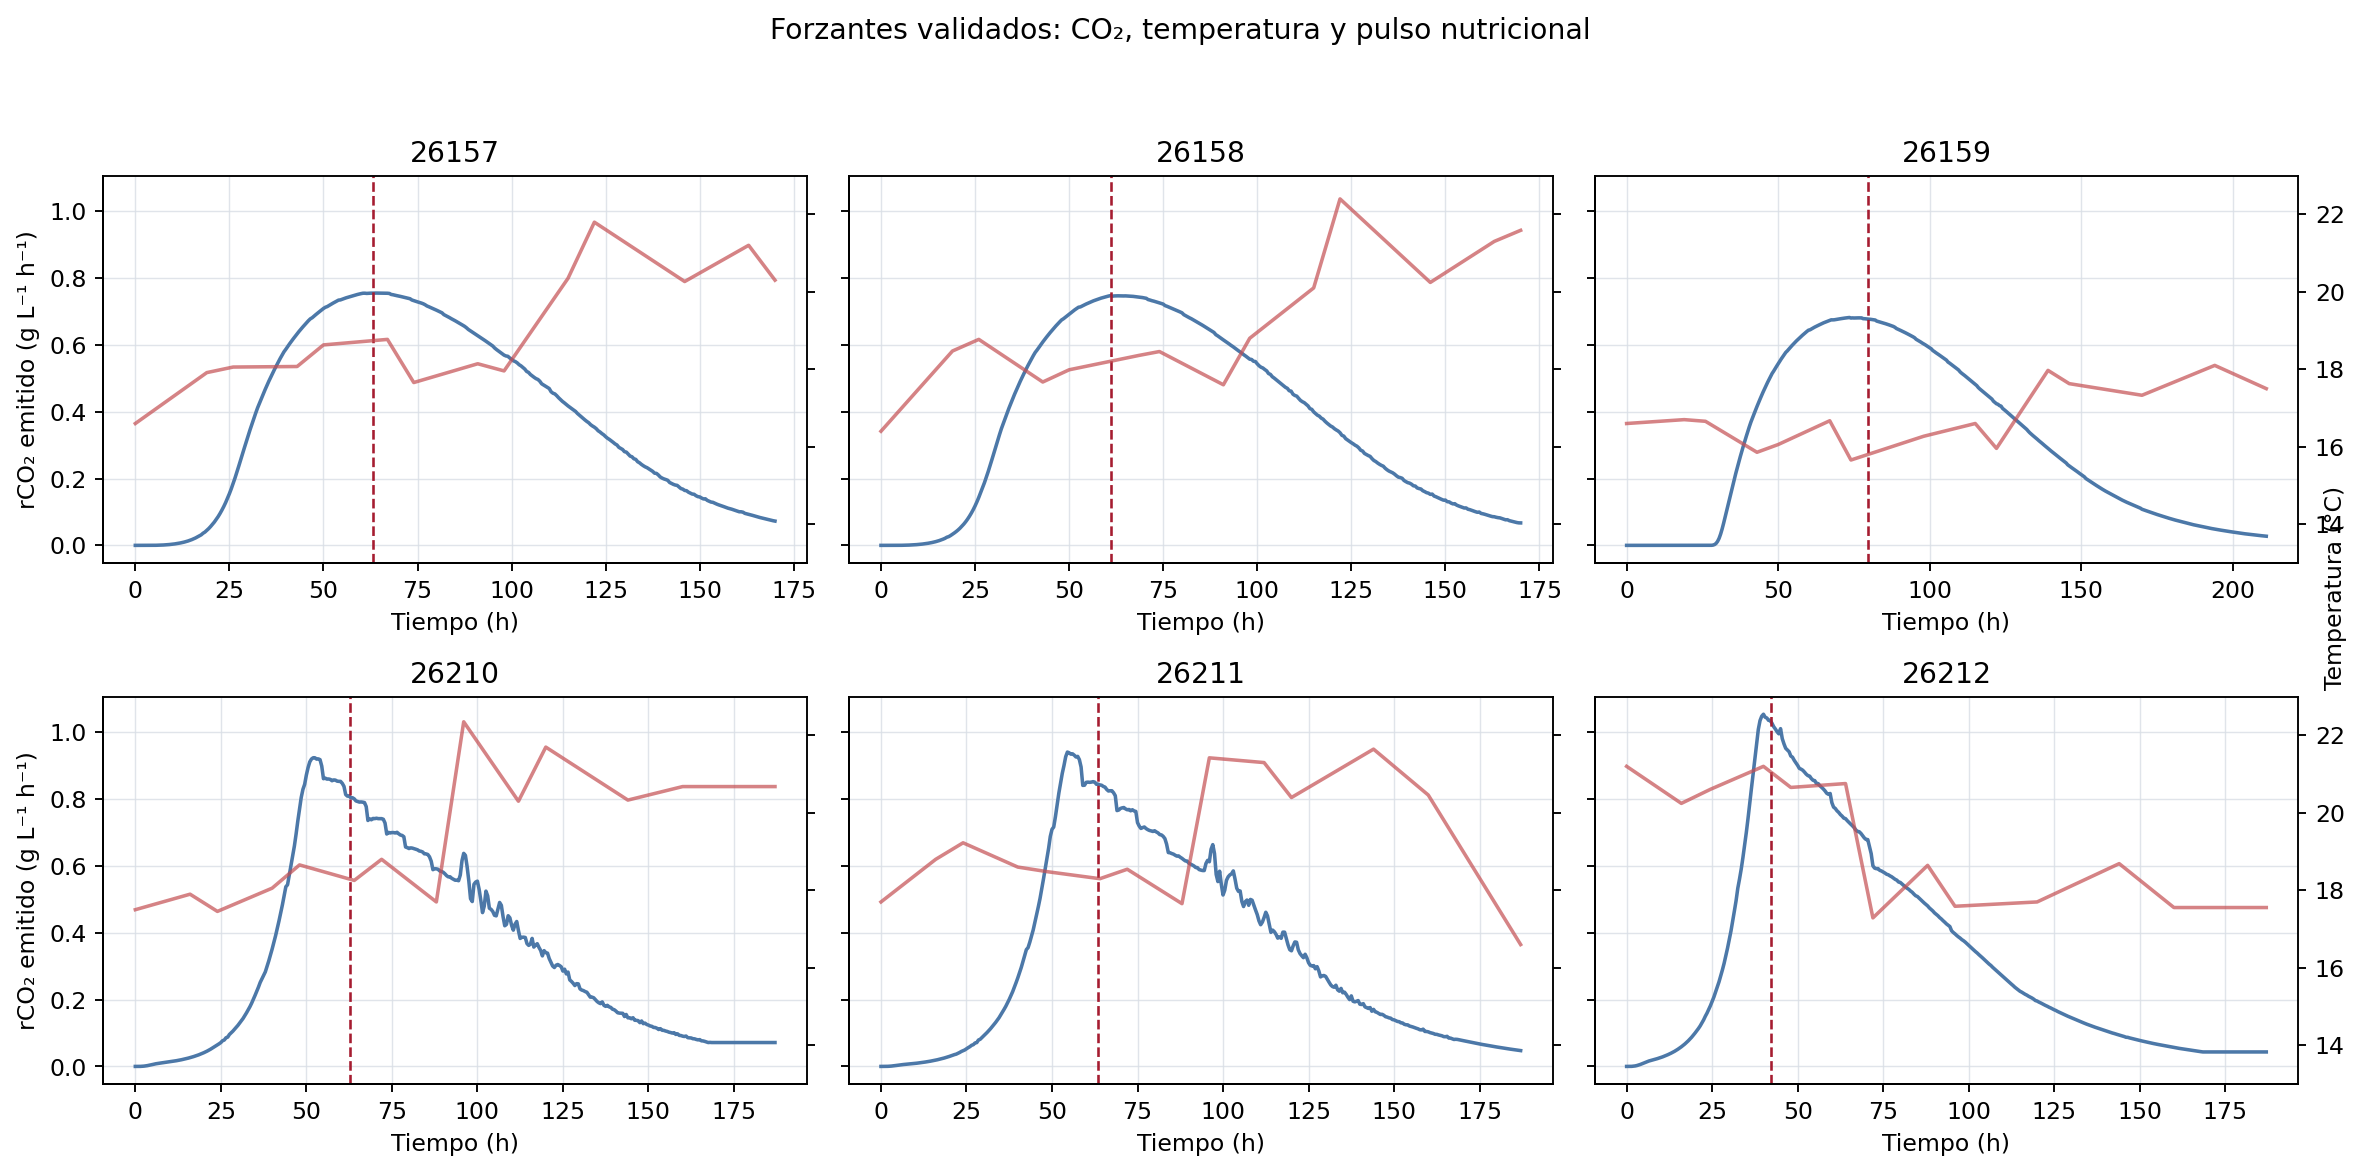

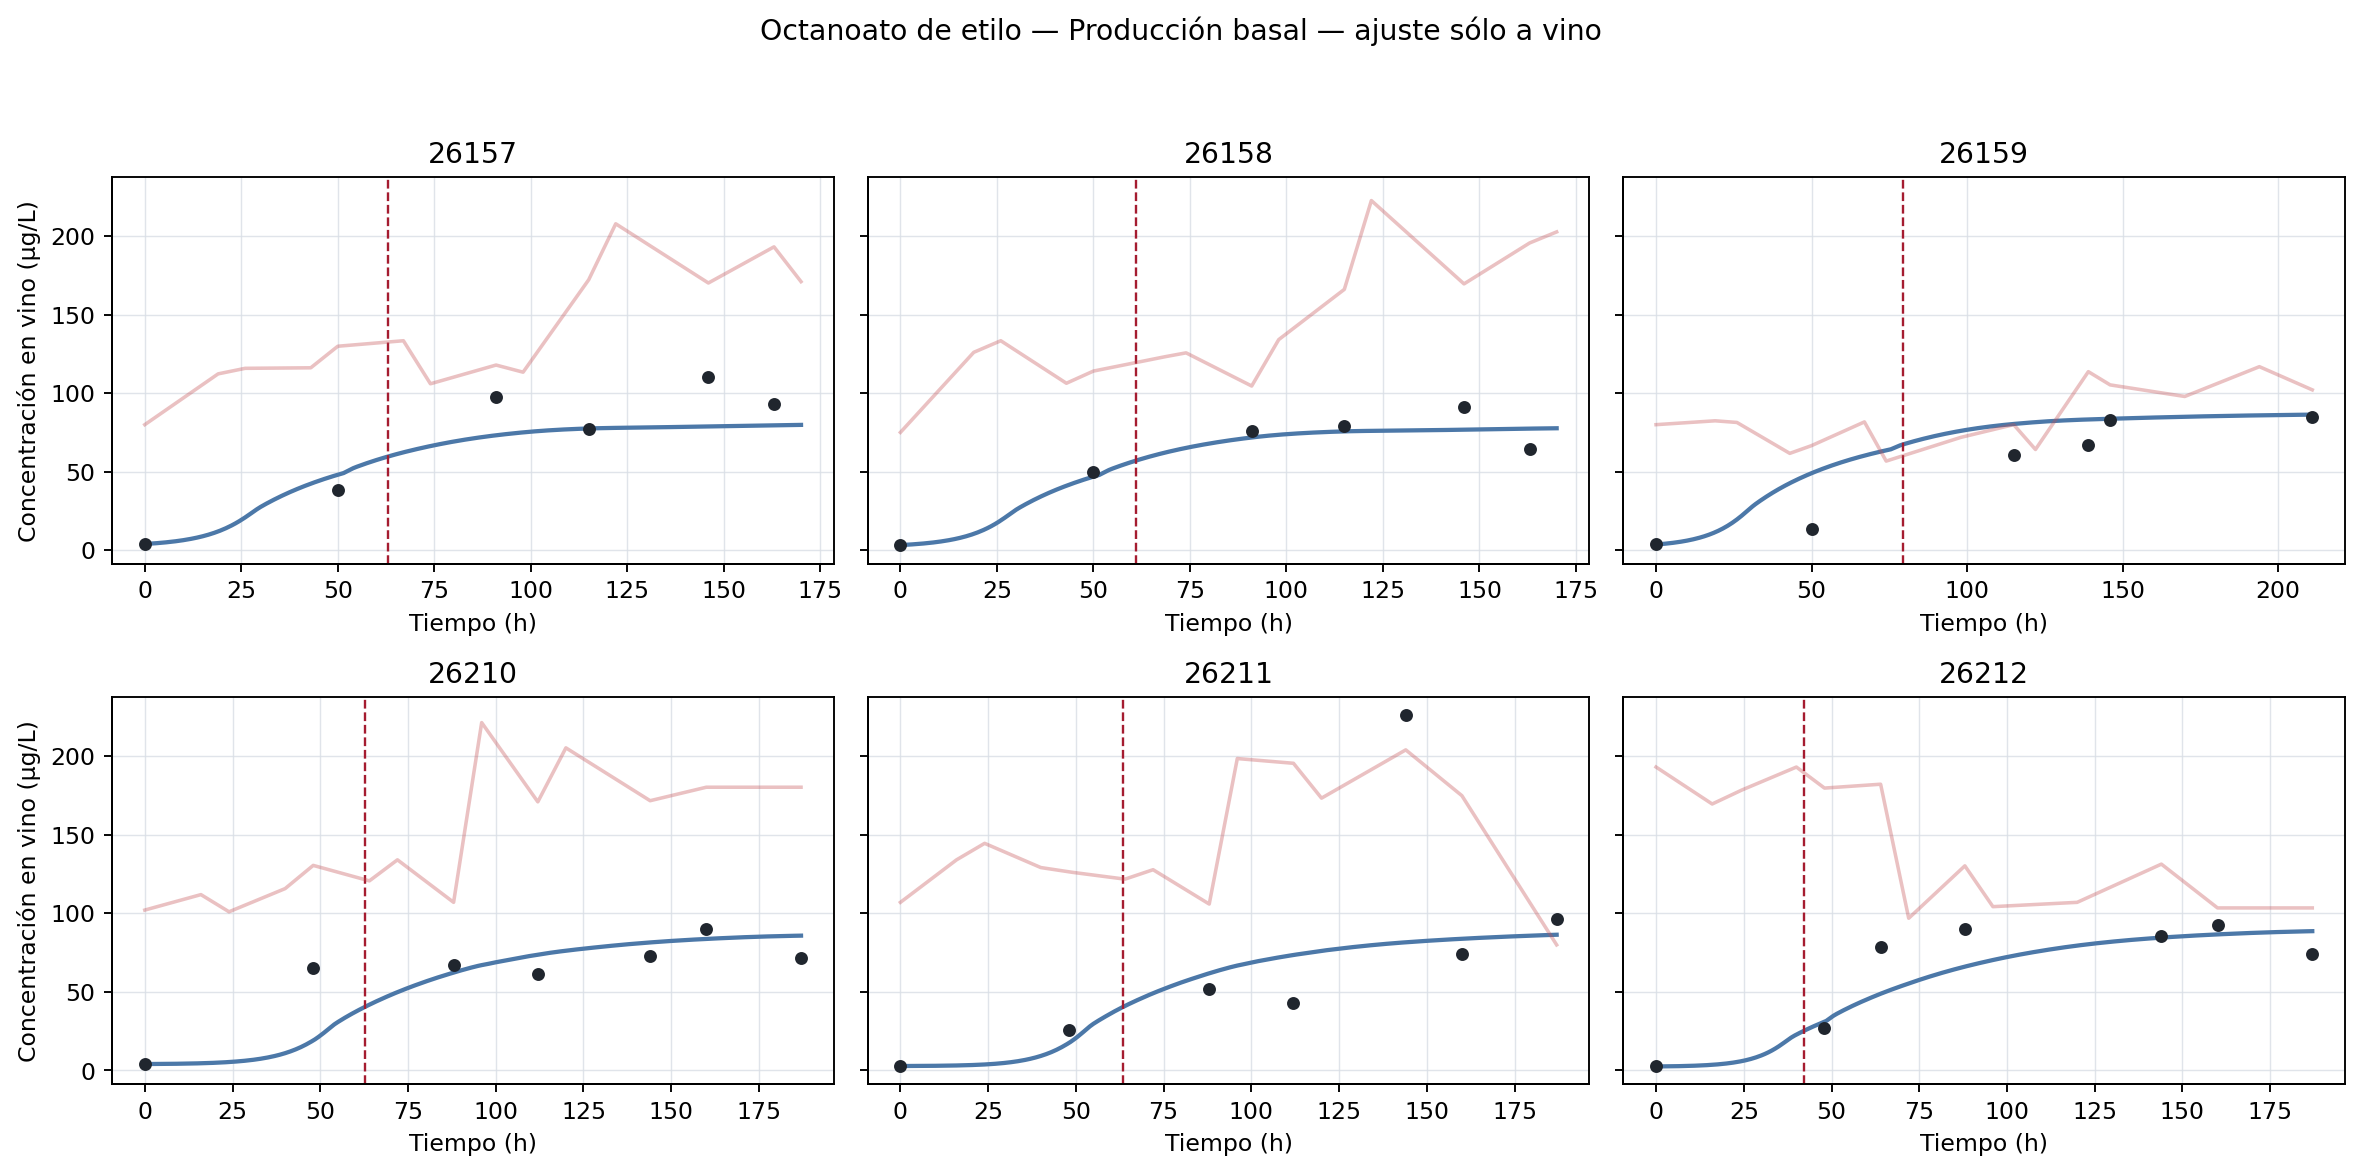

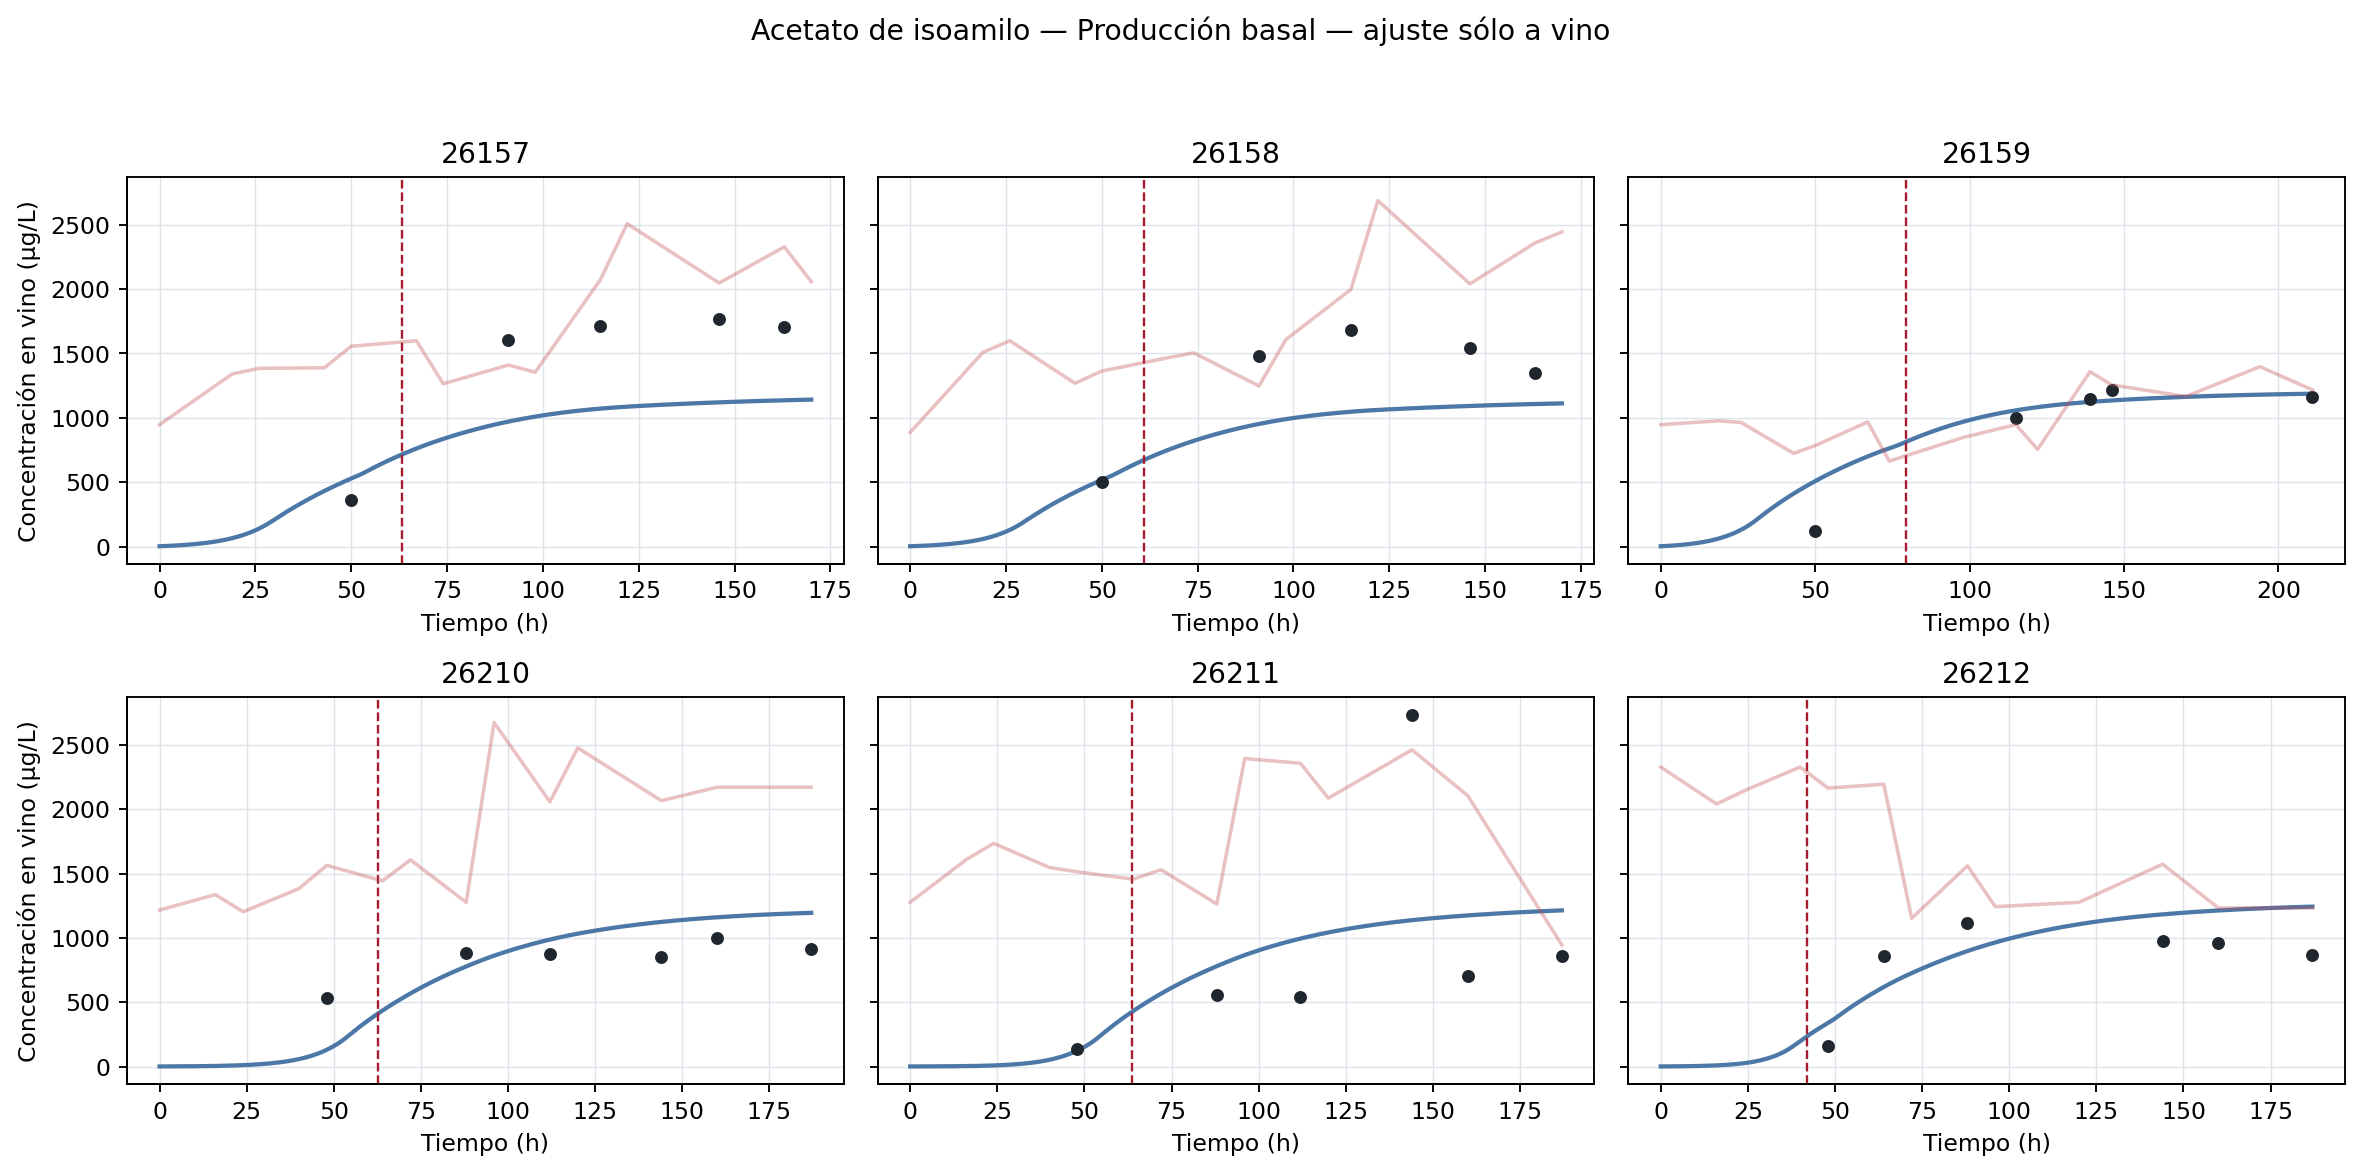

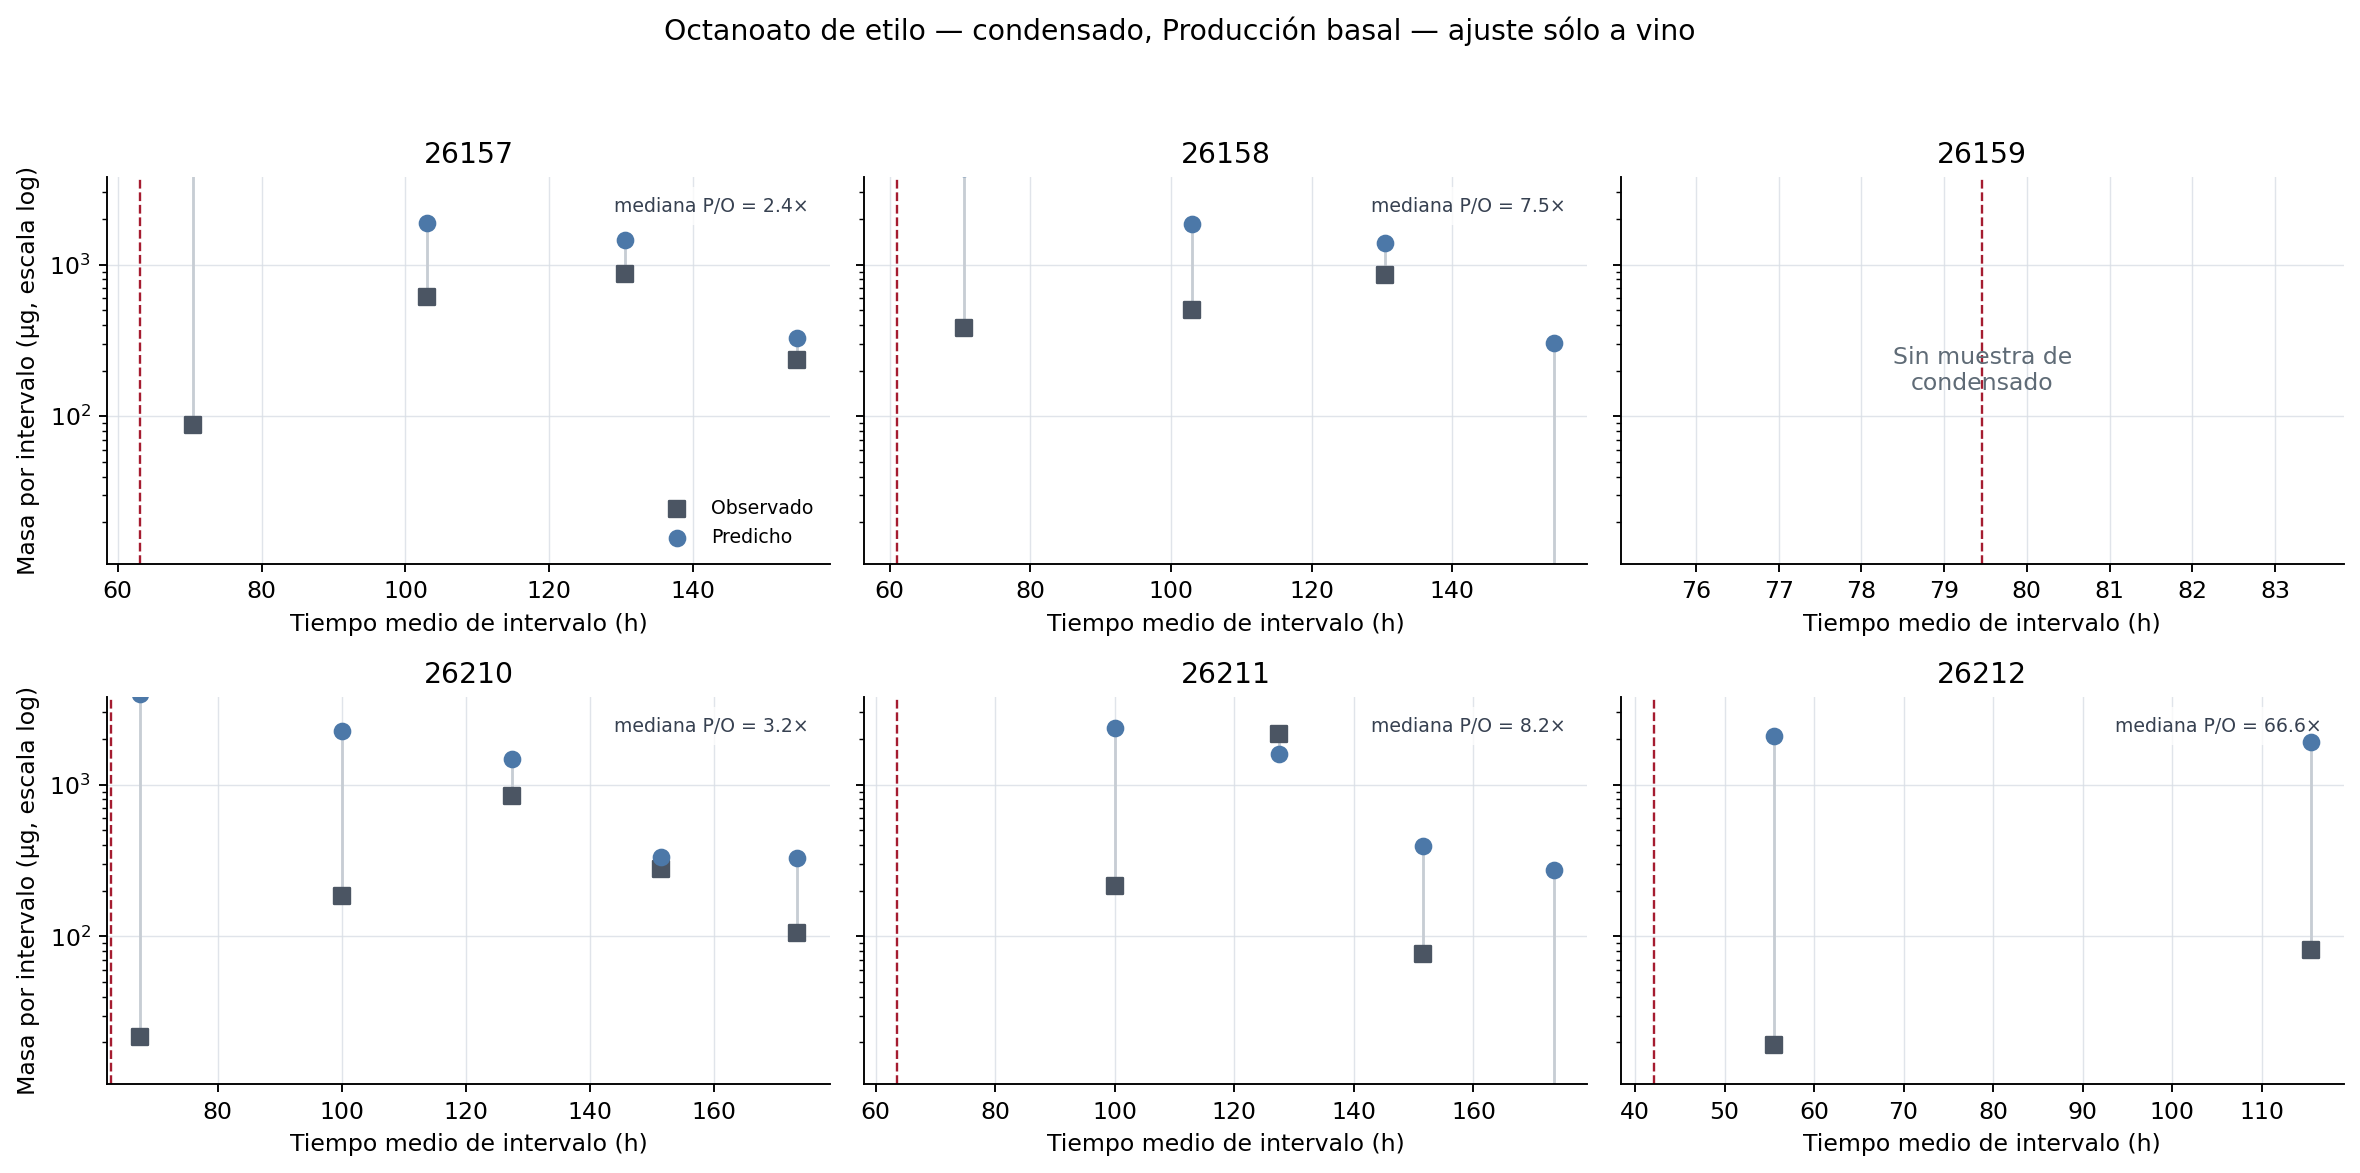

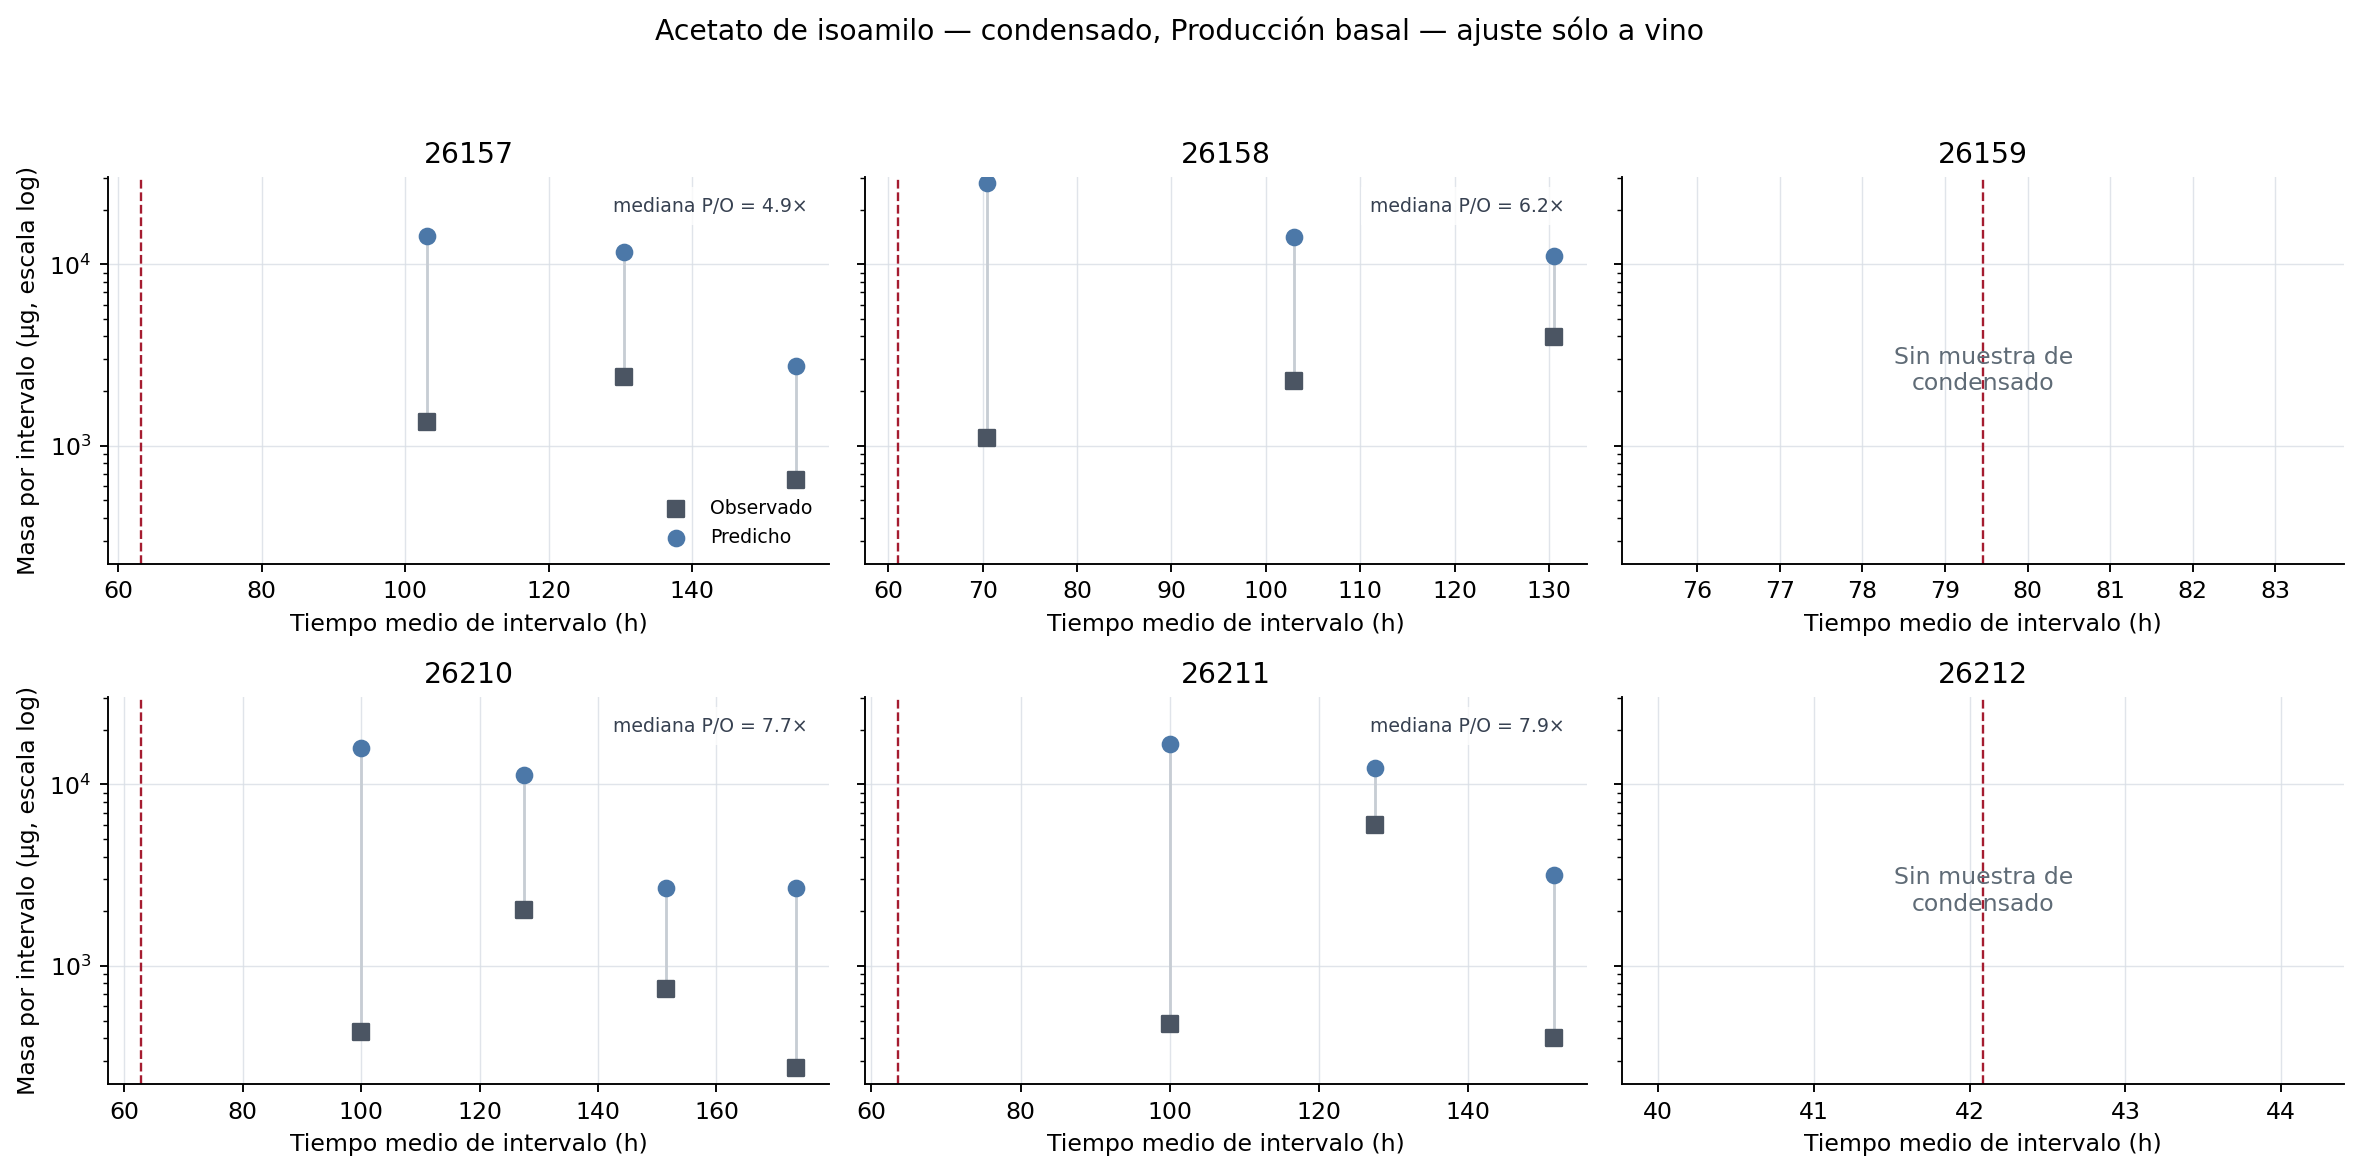

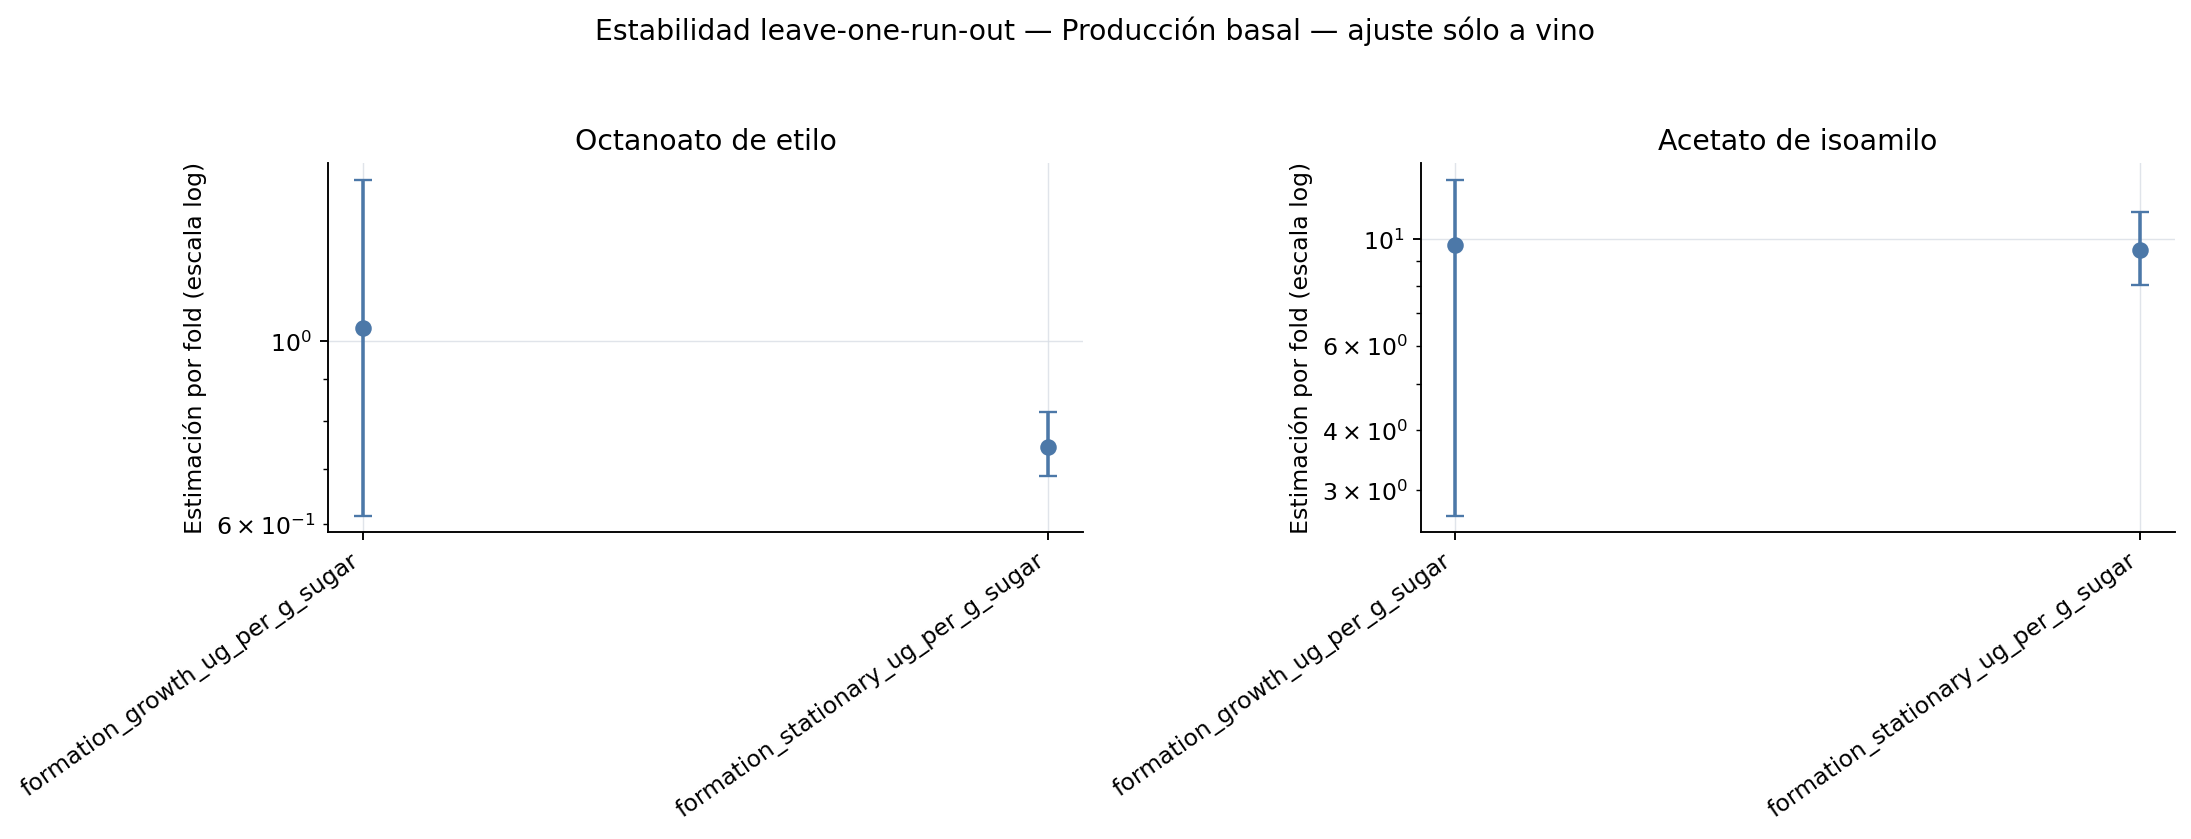

In [4]:
for name in [
    '03_rco2_temperature_pulse_drivers.png',
    '04_liquid_ethyl_octanoate.png',
    '04_liquid_isoamyl_acetate.png',
    '05_condensate_ethyl_octanoate.png',
    '05_condensate_isoamyl_acetate.png',
    '06_parameter_stability.png',
]:
    display(Image(filename=analysis.FIGURE_DIR / name))

## Conclusiones

El ajuste del vino evalúa la estructura biológica sin contaminación del bloque de captura. El condensado evalúa por separado si las pérdidas predichas son compatibles con captura A+B completa. Un fallo de cierre no identifica eficiencia física: rechaza el contrato conjunto bajo la estructura y datos actuales.

In [5]:
assert result['fit_validation']['calibration_domains'].eq('wine').all()
assert result['capture_audit']['fixed_total_capture_fraction'].eq(1.0).all()
assert result['capture_audit']['maximum_absolute_unrecovered_ug'].max() < 1e-8
assert result['fit_validation']['maximum_relative_mass_balance_error'].max() <= 1e-8
print('Notebook ejecutado sin errores; condensado excluido del ajuste.')

Notebook ejecutado sin errores; condensado excluido del ajuste.
